**EVALUACION 1**

Integrante: Alexander López

Introducción:

- Como bien muchos sabemos, deep learning actualmente es muy importante para el dia a dia, ya que deep learning, se encarga de ejecutar redes neuronales artificiales, que estas mismas se basan en ejecutar procesos completamente dificiles, actualmente hay muchos proyectos grandes que tienen implementado esta rama, uno de ellos es el clasico DLSS de nvidia (Deep learning Super Sampling), como otros proyectos mas que se suelen manejar en deep learning

- MNIST, es un dataset que contiene 70000 imagenes totales, en escala de grises de tamaño (28x28), la cual contiene numeros del 0 al 9 de manera manuscrita, 60000 imagenes se ocupan para prueba y 10000 para testeo del mismo.

- En base a esto, se eligira MNIST para este proyecto, el problema que se busca solucionar dentro del proyecto, es implementar y desarrollar un modelo completo de deep learning en base al dataset MNIST, para optimizar modelos, configuracion de hiperparametros para mejorar precisamente el modelo y tambien permitir identificar varias combinaciones diferentes, para ver cual de ellas es mejor para optimizar y por ultimo verificar a traves de metricas, si el desarrollo ha sido el correcto para cada modelado.


# Carga de datos del modelo

**La siguiente celda del codigo, cargara el dataset de MNIST a nivel de nube, pero primeramente para la carga, tenemos que importar todo lo necesario a ocupar**

In [1]:
# Se importa TensorFlow/Keras para la carga del dataset de MNIST, desde internet
from tensorflow import keras

# Se importa Numpy para calculos matematicos dentro del modelo, matrices y arreglos
# dentro del modelo
import numpy as np

# Se importa tensorflow individualmente
import tensorflow as tf

# Se importa matplotlib para la visualizacion de imagenes y de metricas.
from matplotlib import pyplot as plt

# Esta importacion, tiene como fin, visualizacion, manipulacion y analisis
# dentro de los datasets
import pandas as pd

# Se utiliza sklearn para la impresion de las metricas a utilizar
from sklearn.metrics import classification_report

**Estas importaciones son muy importantes, ya que sin ellas, directamente el proyecto nisiquiera se podria trabajar o tomar datos del dataset**

In [2]:
# Para cargar el dataset se ocupara keras, que es parte de tensorflow
# Tambien, se mostraran los datos divididos en entrenamiento y prueba

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
print(x_train.shape) # Muestra las dimensiones y el numero de datos de entrenamiento
print(x_test.shape) # Muestra las dimensiones del los datos de prueba

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(10000, 28, 28)


**El dataset, contiene 60.000 Imagenes de entrenamiento de tamaño (28x28) todos estos, siendo numeros manuscritos y por otra parte**

**Para testeo, contiene 10.000 datos de igual tamaño (28x28), para prueba**

Este apartado es importante, ya que permite verificar que el modelo efectivamente este mostrando todo de manera correcta, tanto la cantidad de imagenes, como el tamaño

# Muestra del dataset / Carga de datos del modelo

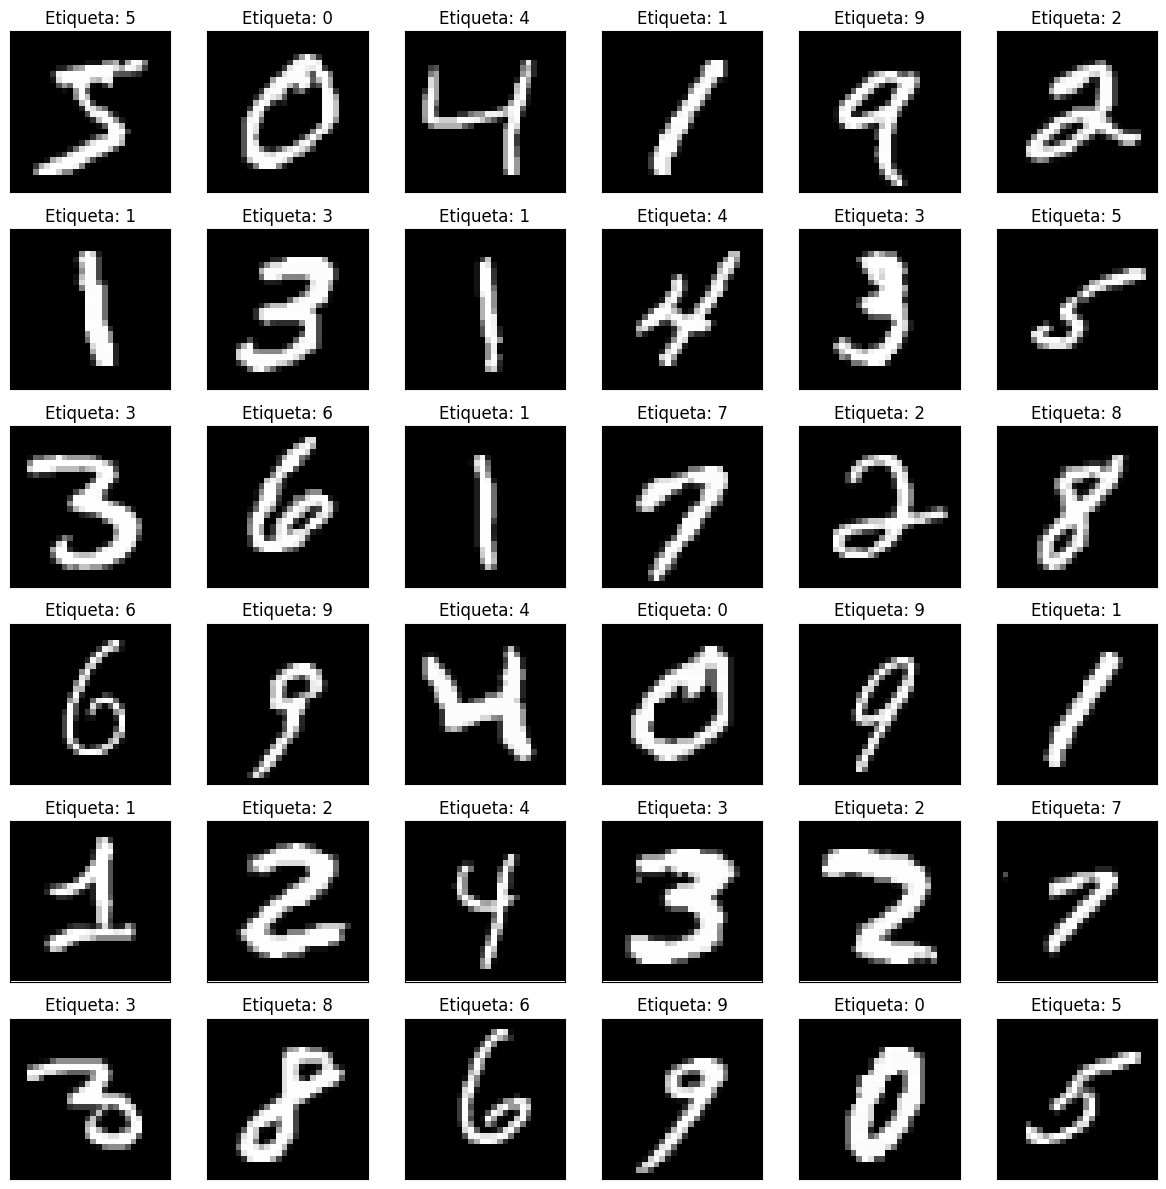

In [3]:
# Se genera la grilla de tamaño 6x6, para ser visualizada posteriormente
# Para mostrar las etiquetas de los datos y el dato original (Numero)
# y el numero de la etiqueta del dato, para ver y visualizar ejemplos del dataset
h = 6 # filas de grilla
w = 6 # Columnas de grilla

#
fig, axs = plt.subplots(h, w, figsize=(2*h, 2*w))

# Recorrer la etiqueta junto con los datos, para posteriormente ser visualizados
for i in range(h):
    for j in range(w):
        idx = i * w + j

        # Ordenar y limpiar la visualizacion antes de ser mostrada
        axs[i, j].imshow(x_train[idx], cmap='gray')
        axs[i, j].set_title(f"Etiqueta: {y_train[idx]}")
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])

plt.tight_layout()
plt.show() # Muestra las etiquetas del test junto con el numero real, para posteriormente visualizarlas

**Este codigo, se encarga de mostrar los datos reales, junto con sus etiquetas
dentro del dataset real de mnist, para explorar los datos antes de ser entrenados**

# Preprocesamiento de datos

Esta fase permite preprocesar los datos crudos antes de precisamente ser entrenados y utilizados por MLP y las redes neuronales, para procesar datos de manera limpia, ordenada, estructurada y clara.

Normalizacion de datos - Transformacion - Integracion

In [4]:
# Se transforma la imagen de matriz 28x28 a un vector de 784, para ser utilizado
# dentro de las redes neuronales artificiales y perceptrones multicapa (MLP)
x_train = x_train.reshape(len(x_train), 784)
x_test = x_test.reshape(len(x_test), 784)

# Despues de ese apartado, se normalizan los valores para ser entrenados y preparados
# para el modelo y asi obteniendo mayor velocidad y rendimiento a la hora del entrenamiento
# y testeo del modelo
x_train = x_train / 255.0
x_test = x_test / 255.0

# Finalmente, se transforma el valor y a formato one hot encoding
# Para tener 10 componentes categoricos
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

Esta fase del preprocesamiento de datos es importante, ya que permite normalizar los valores y datos, antes de que el modelo sea usado y entrenado para las redes neuronales y perceptrones multicapa

# Parte 2 - Definición de la arquitectura

En este apartado, se define la arquitectura a utilizar, la cual sera de perceptron multicapa (MLP)

Se utiliza esta arquitectura, debido a que MNIST trabaja con datos numericos en imagenes blanco y negro, que van desde al 0 al 9, a comparacion de otros modelos mas complejos como pueden ser cifar10 o fashion-mnist que ya tienen una estructura mas completa o compleja que mnist, aplicar un modelo de perceptron manual, directamente no seria lo mas recomendable, ya que mnist es un dataset que viene preentrenado anteriormente, por lo cual el uso del perceptron directamente no es recomendable


por otra parte, mnist es un problema de clasificacion multiclase.

In [5]:
# Comenzamos entrenando la red en base a feed fordward
# donde tambien es muy utilizada para mnist (Muy utilizada en mnist)

# Se entrena el primer modelo a utilizar (Sin optimizacion)
# A medida que se ejecuta el codigo, se van utilizando capas ocultas y sus respectivo codigo de activacion y salida
mlp_base_1 = keras.Sequential([
    keras.layers.Dense(256, activation='relu', input_shape=(784,)), # Se utiliza principalmente la funcion relu, ya que es indicada para problemas de clasificacion multiclase como mnist directamente, y tambien acelera la convergencia del modelo y evita un desvanecimiento del gradiente
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax') # Se utiliza la salida softmax
])

# Se ocupa la compilacion, utilizando primeramente un learning rate de 0.001
# y una perdida categorica, ya que se utiliza one hot encoding
mlp_base_1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mlp_base_1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

En el recuadro que aparece al final, aparece la cantidad de redes entrenables en base al modelo, junto con los parametros totales que se pueden utilizar junto con sus capas (3 totales) cada una describiendo el tamaño y la dimension que van a ocupar

Fase 3 - Entrenamientos del modelo

In [6]:
# A continuacion, se entrena el modelo con #.fit, funcion implementada dentro de
# Tensorflow - Keras, para ejecutar el modelo con los respectivos parametros de entrenamiento
# batch_size - epochs

historial_base = mlp_base_1.fit(
    x_train, y_train,
    epochs=20, # Epocas a ocupar, en este caso 20 epocas totales - Se probo con un total de 50, pero la ejecucion demora una gran cantidad de tiempo
    batch_size=128, # Tamaño del entrenamiento, en este caso 128, para ejecucion mas rapida del codigo
    validation_split=0.1, # Validacion de cada split en base al entrenamiento 90% Entrenamiento 10% prueba
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9126 - loss: 0.3041 - val_accuracy: 0.9662 - val_loss: 0.1169
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9669 - loss: 0.1110 - val_accuracy: 0.9720 - val_loss: 0.0877
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9775 - loss: 0.0727 - val_accuracy: 0.9767 - val_loss: 0.0802
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9838 - loss: 0.0519 - val_accuracy: 0.9798 - val_loss: 0.0733
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9880 - loss: 0.0383 - val_accuracy: 0.9802 - val_loss: 0.0752
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9901 - loss: 0.0303 - val_accuracy: 0.9783 - val_loss: 0.0753
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9918 - loss: 0.0264 - val_accuracy: 0.9807 - val_loss: 0.0692
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9930 - loss: 0.0214 - val_accuracy: 0.

Finalizando la ejecucion del primer modelo base, se ve que el modelo es casi perfecto en cuanto al valor del accuracy, lo cual puede mostrar un overfitting dentro del modelo, para esto, vamos a experimentar con distintos codigos, pero cambiando parametros especificos

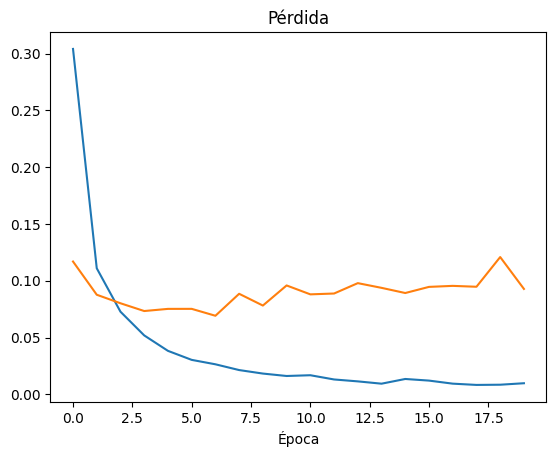

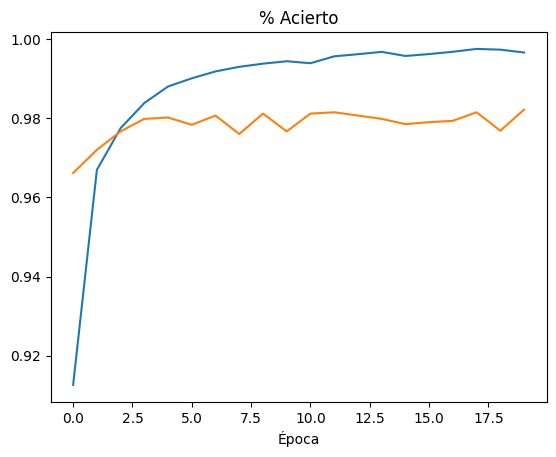

In [7]:
# A continuacion, se muestra un grafico explicativo de la ejecucion del codigo, validando
# entre el entrenamiento y la validacion, en base a la perdida por epocas
plt.plot(historial_base.history['loss'])
plt.plot(historial_base.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(historial_base.history['accuracy'])
plt.plot(historial_base.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

Como se logra ver en el modelo base, la perdida va aumentando de manera gradual a medida que se va ejecutando cada epoca, pero tambien, se muestra un acierto por cada epoca un poco inestable

Experimento 1 - Cambiando Batch size y Epocas - Entrada y salidas

**En este experimento, se probara como experimento cambiar las epocas, tambien se cambiaran los valores de entrada y salida del modelo**

In [8]:
mlp_base_exp1 = keras.Sequential([
    keras.layers.Dense(256, activation='tanh', input_shape=(784,)), # Para este experimento, se probara a cambiar la activacion a una tahn
    keras.layers.Dense(128, activation='tanh'), # en este experimento, se va a probar a utilizar tanh, el cual se basa en corvergencia rapida dentro del modelo
    keras.layers.Dense(64, activation='tanh'),
    keras.layers.Dense(10, activation='softmax') # Se utiliza la salida softmax, ya que es la mas comun para tipos de problemas de clasificacion
])

# Se ocupa la compilacion, utilizando primeramente un learning rate de 0.001
# y una perdida categorica, ya que se utiliza one hot encoding
mlp_base_exp1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

mlp_base_exp1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

Como se puede ver, se ven las distintas capas ocultas, en este caso 3, junto con las capas de salida, que contienen un total de 242,762 parametros

In [9]:
# A continuacion, se entrena el modelo con #.fit,

historial_base_exp1 = mlp_base_exp1.fit(
    x_train, y_train,
    epochs=15, # Epocas a ocupar, en este caso 15 epocas totales, experimentando entre epocas
    batch_size=128, # Tamaño del entrenamiento, en este caso 128, para ejecucion mas rapida del codigo
    validation_split=0.1, # Validacion de cada split en base al entrenamiento 90% Entrenamiento 10% prueba
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8839 - loss: 0.0866 - val_accuracy: 0.9522 - val_loss: 0.0339
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9526 - loss: 0.0319 - val_accuracy: 0.9673 - val_loss: 0.0219
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9668 - loss: 0.0216 - val_accuracy: 0.9722 - val_loss: 0.0177
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9762 - loss: 0.0159 - val_accuracy: 0.9748 - val_loss: 0.0154
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9819 - loss: 0.0121 - val_accuracy: 0.9758 - val_loss: 0.0158
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9860 - loss: 0.0095 - val_accuracy: 0.9778 - val_loss: 0.0138
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9891 - loss: 0.0075 - val_accuracy: 0.9793 - val_loss: 0.0140
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9915 - loss: 0.0060 - val_accuracy: 0.

Cambiando los parametros en este experimento, se noto que al elegir la entrada tanh, se noto un sobreajuste muy claro, siendo que el modelo sale con valores de perdida de mas de 1, por lo cual, esta entrada de salida, directamente no es recomendable para el modelo a optimizar

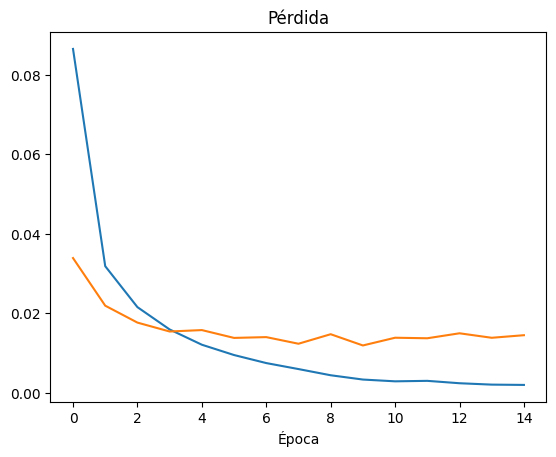

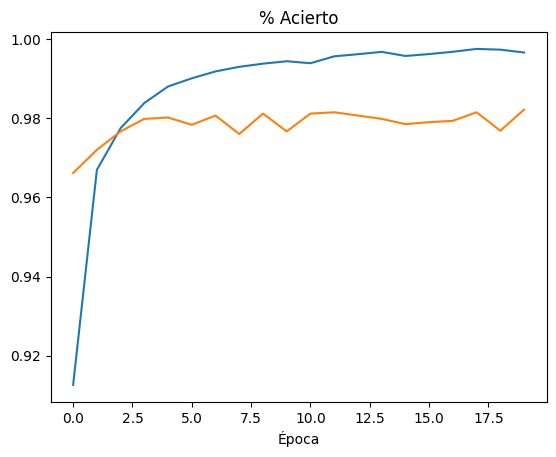

In [11]:
# A continuacion, se muestra un grafico explicativo de la ejecucion del codigo, validando
# entre el entrenamiento y la validacion, en base a la perdida por epocas
plt.plot(historial_base_exp1.history['loss'])
plt.plot(historial_base_exp1.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(historial_base.history['accuracy'])
plt.plot(historial_base.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

Como se logra apreciar en el siguiente grafico, los valores en base a las perdidas por epoca del modelo, se logran apreciar de una manera muy poco constante o inexacta

In [12]:
# En el siguiente recuadro, se comparan en base a ambos modelos, el base y el experimentado, que cambia las funciones de activacion
# Ya que en la segunda, se utiliza tanh en vez de relu, y tambien se baja la cantidad de epocas a 30
# Ambos modelos tienen sobreajuste, pero en el de tanh, se presenta un menor valor

comparacion = pd.DataFrame({
    "Modelo": ["modelo base 1 - Entrenado con 50 epocas)", "modelo experimento 1( modelo con tanh y 30 epocas)"],
    "Accuracy": [historial_base.history["accuracy"][-1],
                 historial_base_exp1.history["accuracy"][-1]],
    "Val Accuracy": [historial_base.history["val_accuracy"][-1],
                     historial_base_exp1.history["val_accuracy"][-1]],
    "Loss": [historial_base.history["loss"][-1],
             historial_base_exp1.history["loss"][-1]]
})

print(comparacion)

                                              Modelo  Accuracy  Val Accuracy  \
0           modelo base 1 - Entrenado con 50 epocas)  0.996593      0.982167   
1  modelo experimento 1( modelo con tanh y 30 epo...  0.997370      0.981667   

       Loss  
0  0.009774  
1  0.001988  


Como se puede notar en ambos modelos, el valor del experimento 1, nota un accuracy o exactitud totalmente perfectos, en la practica no esta bien, ya que claramente el modelo aprendio muy bien de los valores,

**## Experimento controlado 1: cambio de learning rate**

In [13]:
# Experimento controlado 2: cambio de learning rate a 0,01

# En este segundo experimento, se realiza el cambio de learning rate, para ver que tanto afecta un learning rate
# o tasa de aprendizaje mas baja al proyecto

learning_rates = [0.01]
resultados_lr = []

for lr in learning_rates:
    modelo_lr = keras.Sequential([
        keras.layers.Dense(256, activation='relu', input_shape=(784,)),
        keras.layers.Dense(128, activation='relu'), # Se define la activacion relu
        keras.layers.Dense(64, activation='relu'), # ya que es la mas indicada para trabajos multiclase, como MNIST
        keras.layers.Dense(10, activation='softmax') # Se define la salida softmax, ya que es indicada tambien para tipos de trabajo multiclase, aplicando el descenso del gradiente
    ])

    # Se ocupa el optimizador de adam, ya que sin este valor, el codigo directamente no corre en su ejecucion
    modelo_lr.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    # Se entrena el modelo, en este caso
    historial_lr = modelo_lr.fit(
        x_train,
        y_train,
        epochs=20,
        batch_size=128,
        validation_split=0.1
    )

    loss, accuracy = modelo_lr.evaluate(x_test, y_test)
# En esta celda de codigo, se agrega un append, para listar
    resultados_lr.append({
        "Learning Rate": lr,
        "Accuracy": accuracy,
        "Loss": loss,
        "Val Accuracy": historial_lr.history["val_accuracy"][-1],
        "Val Loss": historial_lr.history["val_loss"][-1]
    })

tabla_lr = pd.DataFrame(resultados_lr)
tabla_lr

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9214 - loss: 0.2637 - val_accuracy: 0.9710 - val_loss: 0.1041
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9614 - loss: 0.1311 - val_accuracy: 0.9687 - val_loss: 0.1182
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9682 - loss: 0.1094 - val_accuracy: 0.9690 - val_loss: 0.1042
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9737 - loss: 0.0934 - val_accuracy: 0.9703 - val_loss: 0.1231
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9766 - loss: 0.0844 - val_accuracy: 0.9753 - val_loss: 0.0957
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9775 - loss: 0.0773 - val_accuracy: 0.9690 - val_loss: 0.1261
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9795 - loss: 0.0737 - val_accuracy: 0.9713 - val_loss: 0.1168
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9803 - loss: 0.0738 - val_accuracy: 0.9730 - val_

,Learning Rate,Accuracy,Loss,Val Accuracy,Val Loss
0,0.01,0.9718,0.170601,0.9745,0.140669


En este caso, al cambiar el learning rate del codigo, se ve claramente un accuracy menos exacto a comparacion del modelo con tanh y con relu, esto quiere decir que aprendio bien del modelo, pero al tener un learning rate mas bajo se implementa convergencia dentro del modelo

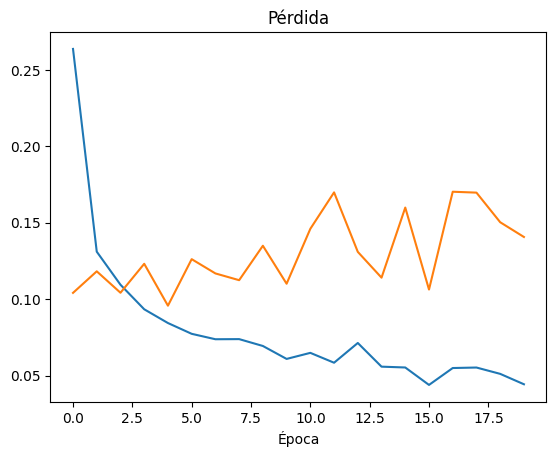

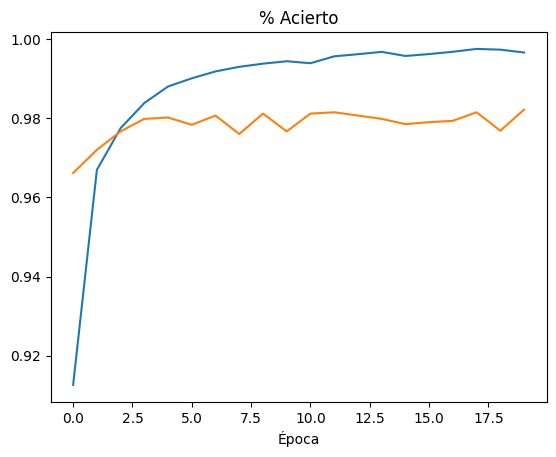

In [14]:
# A continuacion, se muestra un grafico explicativo de la ejecucion del codigo, validando
# entre el entrenamiento y la validacion, en base a la perdida por epocas
plt.plot(historial_lr.history['loss'])
plt.plot(historial_lr.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(historial_base.history['accuracy'])
plt.plot(historial_base.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

Como se logra ver en la ejecucion, aunque el learning rate sea bajo, el modelo aprende igual, pero no es tan exacto, comparado con experimentos basados en cambio de epocas y de activaciones, como en este caso sucedio con el experimento con tanh, esto, teniendo en cuenta que el modelo aprende de la misma manera, aun teniendo un aprendizaje bajo, pero de manera mas lenta, y tambien el grafico, se logra apreciar mas inexacto al igual que los otros modelos

# Comparacion de activacion y error por modelo

In [15]:
# =========================
# MÉTRICAS MODELO BASE (ReLU)
# =========================

# En este apartado de codigo, se calculan las metricas del modelo base
# En base a sus predicciones realizadas, para despues generar un reporte del mismo
# Tambien, se ocupa la libreria pandas para su respectivo funcionamiento

y_true = np.argmax(y_test, axis=1)

y_pred_base = mlp_base_1.predict(x_test)
y_pred_base = np.argmax(y_pred_base, axis=1)

reporte_base = classification_report(y_true, y_pred_base, output_dict=True)
df_base = pd.DataFrame(reporte_base).transpose()

# =========================
# MÉTRICAS DEL MODELO TANH
# =========================
y_pred_tanh = mlp_base_exp1.predict(x_test)
y_pred_tanh = np.argmax(y_pred_tanh, axis=1)

reporte_tanh = classification_report(y_true, y_pred_tanh, output_dict=True)
df_tanh = pd.DataFrame(reporte_tanh).transpose()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


En estos bloques, se compara el experimento con tanh y el modelo base, implementando metricas respectivas para su funcionamiento

In [16]:
# Se evaluan ambos modelos, en este caso el base, que contiene la activacion relu
# y el segundo, que contiene la activacion tanh, en base al loss y el acurracy, tambien
# Se calculan todas las metricas a evaluar
loss_base, acc_base = mlp_base_1.evaluate(x_test, y_test, verbose=0)
loss_tanh, acc_tanh = mlp_base_exp1.evaluate(x_test, y_test, verbose=0)


# Se ocupa la libreria pandas para ejecutar comparaciones de ambas metricas de ambos modelos
# en este caso, tomando en cuenta el modelo con tanh y el modelo con relu
comparacion_metricas = pd.DataFrame({
    "Modelo": ["ReLU", "tanh"],
    "Loss": [ # Se compara primeramente el valor de perdida de ambos modelos
        loss_base,
        loss_tanh
    ],
    "Accuracy": [ # Se compara como primera metrica, la exactitud del modelo
        acc_base,
        acc_tanh
    ],
    "Precision": [ # Se compara como segunda metrica, la precision
        df_base.loc["macro avg", "precision"],
        df_tanh.loc["macro avg", "precision"]
    ],
    "Recall": [ # Se compara como tercera metrica, la sensibilidad o recall del modelo
        df_base.loc["macro avg", "recall"],
        df_tanh.loc["macro avg", "recall"]
    ],
    "F1-score": [ # Y como ultima metrica, s
        df_base.loc["macro avg", "f1-score"],
        df_tanh.loc["macro avg", "f1-score"]
    ]
})

print(comparacion_metricas)

  Modelo      Loss  Accuracy  Precision    Recall  F1-score
0   ReLU  0.112276    0.9790   0.978900  0.978900  0.978837
1   tanh  0.016018    0.9778   0.977601  0.977694  0.977599


Como se puede ver en la comparacion de ambas metricas de ambos modelos, los valores son muy exactos en cuanto a las primeras metricas, pero en el loss, se logra ver una diferencia muy grande entre ambos modelos comparados, esto siendo que tanh tiene una perdida mas baja que el modelo ReLU

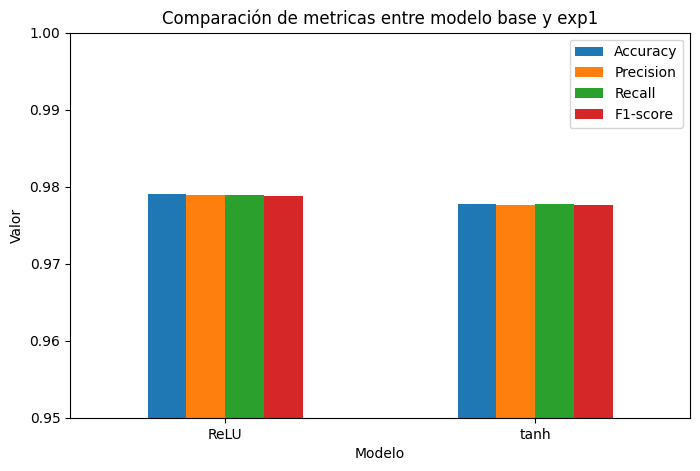

In [17]:
# En este codigo, se comparan las metricas entre los 2 modelos experimentados anteriormente
# con la libreria de matplotlib
comparacion_metricas.set_index("Modelo")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(8,5)
)

# Se realiza el grafico para mostrar ambas metricas de ambos modelos
# en base a la activacion ocupada, en este caso del modelo base y del modelo experimentados
plt.title("Comparación de metricas entre modelo base y exp1")
plt.ylabel("Valor")
plt.xticks(rotation=0)
plt.ylim(0.95, 1.0)
plt.show()

En comparacion con ambas activaciones ocupadas, se ve que el modelo de relu y tanh no cambian demasiado sus valores, esto puede suceder, debido a que ambos modelos no se encuentran optimizados, y tambien se puede ver un modelo demasiado sobreajustado a la hora de entrenarlo, por lo cual, las metricas seran totalmente parecidas entre si en ambos modelos

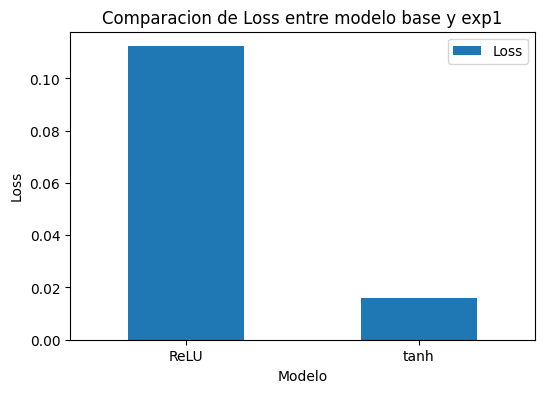

In [18]:
# En este codigo, se prueba un modelo de barras entre la comparacion de loss
# Ocupando varias variables de salida, en este caso relu y tanh
comparacion_metricas.set_index("Modelo")[["Loss"]].plot(
    kind="bar",
    figsize=(6,4)
)
# Se realiza otro grafico comparativo, para ver los valores de perdida o loss entre ambos modelos
# y activaciones
# en base a la activacion ocupada, en este caso del modelo base y del modelo experimentados
plt.title("Comparacion de Loss entre modelo base y exp1")
plt.ylabel("Loss")
plt.xticks(rotation=0)
plt.show()

En el codigo de comparacion de ambas metricas, se puede ver que el modelo base presenta un mayor valor de perdida que el tanh, esto tomando en cuenta que el valor de activacion relu, es el mas efectivo para este tipo de tecnicas

En base a los ajustes realizados, se verifica que el modelo principal es mas factible dentro de todo, ya que evaluando los distintos modelos hechos anteriormente, se nota claramente que el modelo con tahn y cambiando de epocas, tiene mucho sobreajuste, a comparacion del modelo con relu, que directamente tenia un sobreajuste, pero no tan notorio, por esta razon, se justifica ocupar el modelo base, ya que es el mas exacto, junto con el valor de lr de 0.001 y un batch de 128, un batch menor, haria que el modelo se demorara mucho mas en ejecutar, pero seria mas preciso y por ultimo el tamaño de epocas en 50, ya que son suficientes

# Optimizacion de modelo con Tecnicas - DropOut

En este codigo, se probara a ocupar tecnicas de optimizacion dentro del modelo a utilizar, en este caso el primer modelo base que se utilizo, este mismo lo adaptaremos, pero con la diferencia, de que este mismo, sera optimizado con tecnicas muy ocupadas dentro del deep learning - Como DropOut - Regularizacion del batch y muchas mas

In [19]:
# En el siguiente comando, se aplica el codigo optimizado, aplicando tecnicas de optimizacion
# Como DropOut, Una de las mas usadas para evitar un sobreajuste notorio en modelos

# Se define el modelo a utilizar, en este caso siempre sera un feed fordward
# Definiendo el modelo base que teniamos, pero aplicandole un dropout de (0.3)
# En todas las capas ocultas del modelo (Entrada)
# Para evitar el sobreajuste dentro del modelo
mlp_opt = keras.Sequential([
    keras.layers.Dense(256, activation='relu', input_shape=(784,)), # Se utiliza principalmente la funcion relu, ya que es indicada para problemas de clasificacion multiclase como mnist directamente, y tambien acelera la convergencia del modelo y evita un desvanecimiento del gradiente
    keras.layers.Dropout(0.3),
    keras.layers.BatchNormalization(), # Se aplica batch Normalization a todas las neuronas para entrenar el modelo de manera mucho mas rapida y estable
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(10, activation='softmax') # Se utiliza la salida softmax
])
# Dentro del compile, tambien se utiliza el optimizador de adam, uno de los mas estandares y efectivos para modelos multiclase como MNIST
mlp_opt.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001), #Se ocupa un learning rate y un optimizador de adam, ya que entrena redes de manera eficiente y rapida
    loss='categorical_crossentropy', # Se sigue con la perdida categorica, ya que el modelo trabaja con imagenes numericas del (0,9), siendo por orden categorico
    metrics=['accuracy']
)


mlp_opt.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,554 (955.29 KB)

 Trainable params: 243,658 (951.79 KB)

 Non-trainable params: 896 (3.50 KB)

Como se logra ver, los parametros de entrada, en base al batch_normalization, se ven menos capas ocultas, las cuales deberian de ser optimizadas a la hora de realizar el entrenamiento del modelo

In [20]:
# En este codigo, se configuran los hiperparametros a utilizar para el entrenamniento
historial_base_opt = mlp_opt.fit(
    x_train, y_train,
    epochs=20, # Se elige para el procesamiento 20 epocas, ya que es un buen tamaño de epocas, para un tamaño de batch, tan alto como es 128
    batch_size=128, # Se elige un batch size de 128, para una ejecucion mucho mas rapido de cada epoca
    validation_split=0.1, # Validacion de cada split en base al entrenamiento 90% Entrenamiento 10% prueba
)

# Estos valores se ajustaron al modelo, ya que al aplicar epocas y batch sizes diferentes, aunque el codigo estuviera optimizado
# Su ejecucion demora una gran cantidad de tiempo, obteniendo valores y ajustes totalmente similares

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8383 - loss: 0.5437 - val_accuracy: 0.9642 - val_loss: 0.1281
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9325 - loss: 0.2359 - val_accuracy: 0.9710 - val_loss: 0.0942
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9471 - loss: 0.1853 - val_accuracy: 0.9742 - val_loss: 0.0845
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9580 - loss: 0.1519 - val_accuracy: 0.9750 - val_loss: 0.0828
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9610 - loss: 0.1371 - val_accuracy: 0.9772 - val_loss: 0.0725
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9649 - loss: 0.1221 - val_accuracy: 0.9773 - val_loss: 0.0745
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9671 - loss: 0.1135 - val_accuracy: 0.9778 - val_loss: 0.0720
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9689 - loss: 0.1044 - val_accuracy: 0

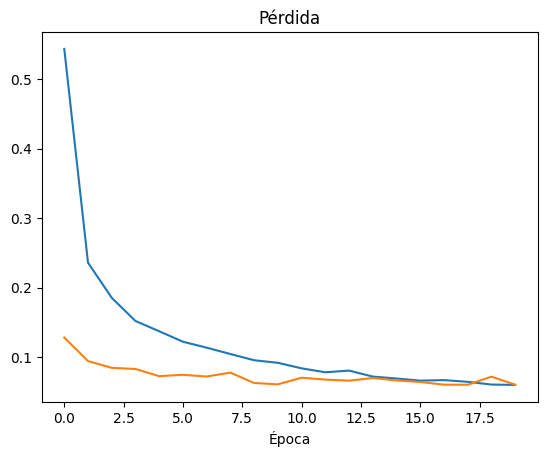

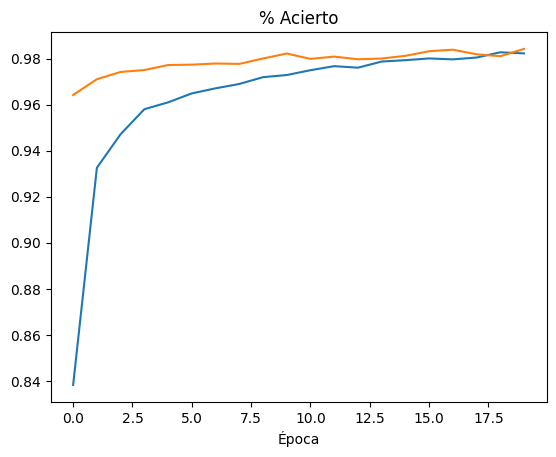

In [21]:
# Se muestran 2 graficos comparacion, el primero es de perdida por epocas
# y el segundo es basado en el acierto por epoca de cada modelo

plt.plot(historial_base_opt.history['loss'])
plt.plot(historial_base_opt.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(historial_base_opt.history['accuracy'])
plt.plot(historial_base_opt.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

Como se puede ver en el grafico, a comparacion con los modelos base, en el optimizado, se logra ver un modelo totalmente mas estable en comparacion con los otros modelos que se presentaban anteriormente, como el base con relu o el experimentado con tanh, eso fue a que gracias a los optimizadores, se logro estabilizar el modelo en general entre acierto y perdida por epoca

# Comparacion de metricas

En este apartado, se compararan distintas metricas en base a los distintos modelos, primeramente comenzando

In [31]:
# Se utiliza el mismo codigo para comparar ambos modelos, pero en este caso, se cambia el modelo con experimento
# tanh por el optimizado

# =========================
# MÉTRICAS MODELO BASE (ReLU)
# =========================

# En este apartado de codigo, se calculan las metricas del modelo base
# En base a sus predicciones realizadas, para despues generar un reporte del mismo
# Tambien, se ocupa la libreria pandas para su respectivo funcionamiento

y_true = np.argmax(y_test, axis=1)

y_pred_base = mlp_base_1.predict(x_test)
y_pred_base = np.argmax(y_pred_base, axis=1)

reporte_base = classification_report(y_true, y_pred_base, output_dict=True)
df_base = pd.DataFrame(reporte_base).transpose()

# =========================
# MÉTRICAS DEL MODELO OPTIMIZADO
# =========================

y_pred_opt = mlp_opt.predict(x_test)
y_pred_opt = np.argmax(y_pred_opt, axis=1)

reporte_opt = classification_report(y_true, y_pred_opt, output_dict=True)
df_opt = pd.DataFrame(reporte_opt).transpose()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Este apartado de codigo, permite calcular metricas con la extension de pandas, esto sirve para comparar metricas y generar los reportes por cada modelo

In [35]:
# En el siguiente codigo, se vera una comparacion entre ambos modelos, el base y el optimizado
# Experimentando varias metricas

# Se evaluan ambos modelos, en este caso el base, que contiene la activacion relu
# y el segundo, que contiene la activacion tanh, en base al loss y el acurracy, tambien
# Se calculan todas las metricas a evaluar
loss_base, acc_base = mlp_base_1.evaluate(x_test, y_test, verbose=0)
loss_opt, acc_opt = mlp_opt.evaluate(x_test, y_test, verbose=0)


# Se ocupa la libreria pandas para ejecutar comparaciones de ambas metricas de ambos modelos
# en este caso, tomando en cuenta el modelo con tanh y el modelo con relu
comparacion_metricas_modelos = pd.DataFrame({
    "Modelo": ["Base", "Optimizado"],
    "Loss": [ # Se compara primeramente el valor de perdida de ambos modelos
        loss_base,
        loss_opt    ],
    "Accuracy": [ # Se compara como primera metrica, la exactitud del modelo
        acc_base,
        acc_opt,
    ],
    "Precision": [ # Se compara como segunda metrica, la precision
        df_base.loc["macro avg", "precision"],
        df_opt.loc["macro avg", "precision"]
    ],
    "Recall": [ # Se compara como tercera metrica, la sensibilidad o recall del modelo
        df_base.loc["macro avg", "recall"],
        df_opt.loc["macro avg", "recall"]
    ],
    "F1-score": [ # Y como ultima metrica, se evalua el f1 score, que compara la precision y el recall juntos
        df_base.loc["macro avg", "f1-score"],
        df_opt.loc["macro avg", "f1-score"]
    ]
})

print(comparacion_metricas_modelos)

       Modelo      Loss  Accuracy  Precision   Recall  F1-score
0        Base  0.112276    0.9790   0.978900  0.97890  0.978837
1  Optimizado  0.068770    0.9816   0.981636  0.98139  0.981490


Como se logra ver, en el modelo base con relu, se nota una leve mejoria en cuanto a la ejecucion, utilizando los mismos parametros y mismas funciones, esto sucedio, gracias a que el dropout y el

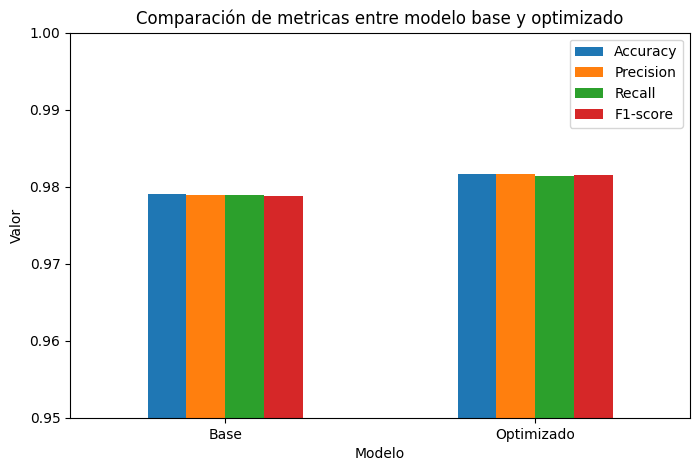

In [37]:
# En este codigo, se comparan las metricas entre los 2 modelos experimentados anteriormente
# con la libreria de matplotlib
comparacion_metricas_modelos.set_index("Modelo")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(8,5)
)

# Se realiza el grafico para mostrar ambas metricas de ambos modelos
# en base a la activacion ocupada, en este caso del modelo base y del modelo optimizado
plt.title("Comparación de metricas entre modelo base y optimizado")
plt.ylabel("Valor")
plt.xticks(rotation=0)
plt.ylim(0.95, 1.0)
plt.show()

En base a la ejecucion, se mostro que el modelo optimizado, alcanzo un aprendizaje muy notorio, comparado con los demas modelos, que directamente presentaban un sobreajuste claro y un grafico muy desbalanceado

In [43]:
# Tabla comparativa de resultados entre los 4 modelos finales

# Se utiliza el mismo codigo para comparar ambos modelos, pero en este caso, se cambia el modelo con experimento
# tanh por el optimizado

# =========================
# MÉTRICAS MODELO BASE (ReLU)
# =========================

# En este apartado de codigo, se calculan las metricas del modelo base
# En base a sus predicciones realizadas, para despues generar un reporte del mismo
# Tambien, se ocupa la libreria pandas para su respectivo funcionamiento

y_true = np.argmax(y_test, axis=1)

y_pred_base = mlp_base_1.predict(x_test) # Se define las predicciones base, aplicandose a todos los modelos
y_pred_base = np.argmax(y_pred_base, axis=1)

reporte_base = classification_report(y_true, y_pred_base, output_dict=True)
df_base = pd.DataFrame(reporte_base).transpose() # Se configura con pandas para generar un reporte de clasificacion de todos los modelos utilizados, para despues analizar en un grafico aparte, las metricas

# =========================
# MÉTRICAS DEL MODELO EXPERIMENTO 2 - TANH Y EPOCAS CAMBIADAS
# =========================

y_pred_tanh = mlp_base_exp1.predict(x_test)
y_pred_tanh = np.argmax(y_pred_tanh, axis=1)

reporte_tanh = classification_report(y_true, y_pred_tanh, output_dict=True)

# =========================
# MÉTRICAS DEL MODELO EXPERIMENTO 3 - Cambio de learning rate
# =========================

y_pred_lr = modelo_lr.predict(x_test)
y_pred_lr = np.argmax(y_pred_lr, axis=1)

reporte_lr = classification_report(y_true, y_pred_lr, output_dict=True)
df_lr = pd.DataFrame(reporte_lr).transpose()
# =========================
# MÉTRICAS DEL MODELO FINAL (Optimizado)
# =========================

y_pred_opt = mlp_opt.predict(x_test)
y_pred_opt = np.argmax(y_pred_opt, axis=1)

reporte_opt = classification_report(y_true, y_pred_opt, output_dict=True)
df_opt = pd.DataFrame(reporte_opt).transpose()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [50]:
# En el siguiente codigo, se vera una comparacion entre ambos modelos, el base y el optimizado
# Experimentando varias metricas

# Se evaluan ambos modelos, en este caso el base, que contiene la activacion relu
# y el segundo, que contiene la activacion tanh, en base al loss y el acurracy, tambien
# Se calculan todas las metricas a evaluar
loss_base, acc_base = mlp_base_1.evaluate(x_test, y_test, verbose=0)
loss_tanh, acc_tanh = mlp_base_exp1.evaluate(x_test, y_test, verbose=0)
loss_lr, acc_lr = modelo_lr.evaluate(x_test, y_test, verbose=0)
loss_opt, acc_opt = mlp_opt.evaluate(x_test, y_test, verbose=0)


# Se ocupa la libreria pandas para ejecutar comparaciones de ambas metricas de ambos modelos
# en este caso, tomando en cuenta el modelo con tanh y el modelo con relu
comparacion_metricas_modelos_final = pd.DataFrame({
    "Modelo": ["Base","Experimento 1","Experimento lr", "Optimizado"],
    "Loss": [ # Se compara primeramente el valor de perdida de ambos modelos
        loss_base,
        loss_tanh,
        loss_lr,
        loss_opt
              ],
    "Accuracy":[ # Se compara como primera metrica, la exactitud del modelo
        acc_base,
        acc_tanh,
        acc_lr,
        acc_opt
    ],
    "Precision": [ # Se compara como segunda metrica, la precision
        df_base.loc["macro avg", "precision"],
        df_tanh.loc["macro avg", "precision"],
        df_lr.loc["macro avg", "precision"],
        df_opt.loc["macro avg", "precision"]
    ],
    "Recall": [ # Se compara como tercera metrica, la sensibilidad o recall del modelo
        df_base.loc["macro avg", "recall"],
        df_tanh.loc["macro avg", "recall"],
        df_lr.loc["macro avg", "recall"],
        df_opt.loc["macro avg", "recall"]
    ],
    "F1-score": [ # Y como ultima metrica, se evalua el f1 score, que compara la precision y el recall juntos
        df_base.loc["macro avg", "f1-score"],
        df_tanh.loc["macro avg", "f1-score"],
        df_lr.loc["macro avg", "f1-score"],
        df_opt.loc["macro avg", "f1-score"]
    ]
})

print(comparacion_metricas_modelos_final)

           Modelo      Loss  Accuracy  Precision    Recall  F1-score
0            Base  0.112276    0.9790   0.978900  0.978900  0.978837
1   Experimento 1  0.016018    0.9778   0.977601  0.977694  0.977599
2  Experimento lr  0.170601    0.9718   0.971422  0.971714  0.971493
3      Optimizado  0.068770    0.9816   0.981636  0.981390  0.981490


Como ultima comparacion, se logra ver que los 4 modelos entrenados tienen metricas muy parecidas, pero el optimizado, gana en cuanto a valores mas estables, en comparaciones con los otros modelos utilizados, que variaban mucho graficamente y el grafico, tenia mucha dispersion entre si

# Conclusion

Como conclusion, el proyecto realizado, primeramente buscaba el comprobar que hiperparametros eran los recomendados para cada tipo de ejecucion, en este caso las tasas de aprendizajes, ya que aunque se ejecutaran mas epocas, el resultado de los modelos no variaba en lo absoluto, donde si empezo a variar el modelo, fue en el cambio del learning rate, donde un experimento con learning rate menor, hizo que el modelo tuviera menor exactitud a comparacion de los otros, tambien en base a eso, se pudo mejorar el modelo base, aplicando optimizaciones con tensorflow, como DropOut y normalizacion de batch, una mejora a futuro, podria ser el ejecutar el codigo con mayores epocas y un mayor batch_size, pero eso hubiera hecho que la ejecucion hubiera sido eterna y hubiera entregado resultados exactamente similares, pero generalmente, el desempeño de el modelo final y optimizado, fue muy bueno, mientras que el base tuvo demasiado sobreajuste, lo cual se mejoro en el codigo optimizado, implementando tecnicas de optimizacion como dropout o normalizacion, por lo tanto, el modelo si logro aprender de una manera totalmente estable  

# Anexos Utilizados

- https://www.tensorflow.org/api_docs

- Codigos Vistos en clase

- https://pandas.pydata.org/

- https://scikit-learn.org/stable/